In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
cd /content/gdrive/My Drive/Colab Notebooks/

/content/gdrive/My Drive/Colab Notebooks


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, silhouette_score

import warnings
warnings.filterwarnings('ignore')

# **1. Loading Data**

In [4]:
df = pd.read_csv('Country-data.csv')

In [5]:
X = df.drop(columns=['country'])

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **2. Clustering**

K-Means

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment_KMeans'] = kmeans.fit_predict(X_scaled)
silhouette_avg = silhouette_score(X_scaled, df['Segment_KMeans'])
print(f"K-Means Silhouette Score: {silhouette_avg:.3f}")

K-Means Silhouette Score: 0.286


DBSCAN

In [8]:
dbscan = DBSCAN(eps=2.0, min_samples=5)
df['Segment_DBSCAN'] = dbscan.fit_predict(X_scaled)
outliers = len(df[df['Segment_DBSCAN'] == -1])
print(f"DBSCAN identified {outliers} anomaly/outlier profiles.")

DBSCAN identified 15 anomaly/outlier profiles.


Visualization: PCA for 2D Plotting

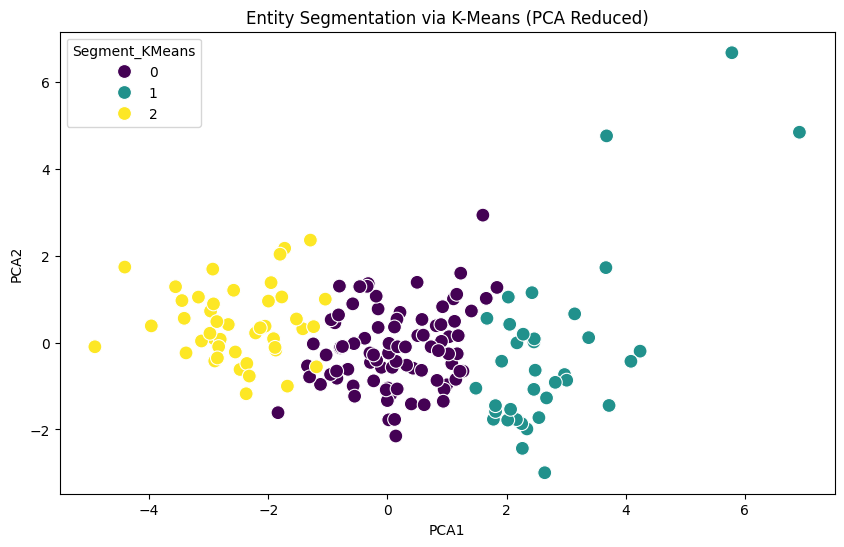

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Segment_KMeans', data=df, palette='viridis', s=100)
plt.title('Entity Segmentation via K-Means (PCA Reduced)')
plt.show()

# **3. Classification**

In [10]:
y = df['Segment_KMeans']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

Random Forest

In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.3f}")

Random Forest Accuracy: 0.971


XGBoost

In [12]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.3f}")

XGBoost Accuracy: 0.971


# **4. Actionable Insights**

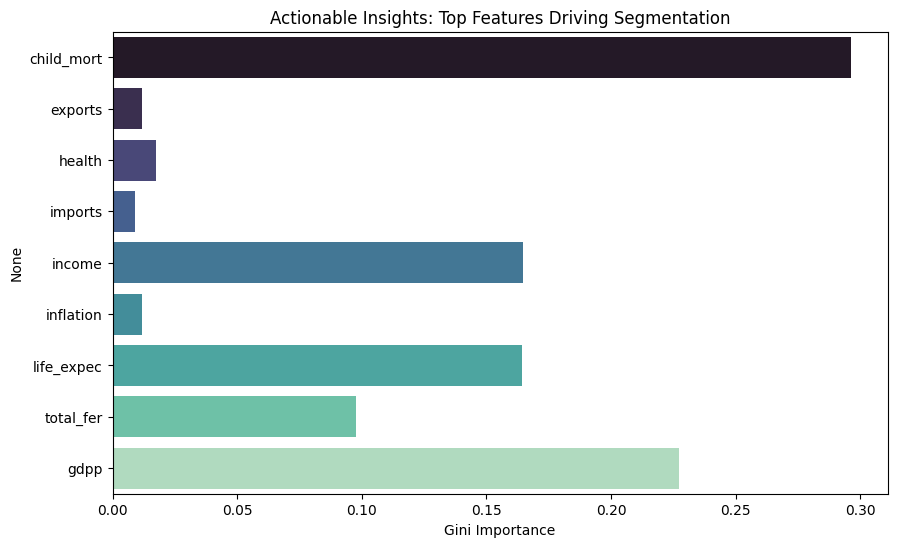

In [13]:
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
sns.barplot(x=importances, y=X.columns, palette='mako')
plt.title('Actionable Insights: Top Features Driving Segmentation')
plt.xlabel('Gini Importance')
plt.show()